# It Takes Time: Temporal Collaborative Filtering Benchmark

Goal: rank a battery of sequential / temporal collaborative-filtering models on
**MovieLens-1M** under a single, reproducible methodology, and produce a results
table that's easy to extend with custom variants.

**Models compared (v1)**

| Family | Models |
|---|---|
| Non-sequential baselines | `Pop`, `BPR`, `ItemKNN` |
| Sequential SOTA | `FPMC`, `GRU4Rec`, `NARM`, `SASRec`, `BERT4Rec` |

**Methodology**

- Dataset: MovieLens-1M, filtered to users / items with ≥ 5 interactions.
- Split: leave-one-out per user, sorted chronologically (RecBole `LS=valid_and_test`, `order=TO`).
  Last interaction → test, second-to-last → validation, the rest → train.
- HPO: Optuna with TPE sampler + MedianPruner. `N_TRIALS=5` by default —
  scale up by setting the `N_TRIALS` env var.
- Eval: full-vocabulary scoring (`mode='full'`) → HitRate, NDCG, MRR, Recall, Precision @ {10, 20, 50, 100}.
- Resumability: each model's eval result is persisted as JSON under
  `results/eval/<dataset>__<model>.json`. Re-running the benchmark cell skips any
  model whose JSON already exists. Optuna studies persist to SQLite under
  `results/hpo/`, so HPO trials also resume.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import optuna

import config
from data import prepare_recbole_dataset, dataset_stats
from models import MODEL_REGISTRY, list_models
from hpo import run_optuna
from runner import train_and_eval, has_result, load_result
from evaluation import aggregate_results, top_k_recommend

print('device:', config.DEVICE)
print('models:', list_models())
print('N_TRIALS:', config.N_TRIALS, '| HPO_EPOCHS:', config.HPO_EPOCHS, '| FINAL_EPOCHS:', config.FINAL_EPOCHS)

2026-05-09 20:21:08.872673: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 20:21:08.944237: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 20:21:10.583798: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


device: cuda
models: ['Pop', 'BPR', 'ItemKNN', 'FPMC', 'GRU4Rec', 'NARM', 'SASRec', 'BERT4Rec']
N_TRIALS: 10 | HPO_EPOCHS: 10 | FINAL_EPOCHS: 50


## 2. Dataset preparation

Downloads MovieLens-1M (~6 MB) on first run, converts to RecBole atomic-file
format, and caches under `recbole_data/ml-1m/ml-1m.inter`. Subsequent runs are no-ops.

In [2]:
DATASET = 'ml-1m'
prepare_recbole_dataset(DATASET)
stats = dataset_stats(DATASET)
pd.Series(stats).to_frame('value')

,value
interactions,1.000209e+06
users,6.040000e+03
items,3.706000e+03
density,4.468363e-02
min_ts,9.567039e+08
max_ts,1.046455e+09


## 3. Run benchmark (resumable)

Loops the model registry. For each model:

1. If `results/eval/<dataset>__<model>.json` exists → load it, skip training.
2. Otherwise: run Optuna HPO, then a final fit on the best params, persist JSON.

Interrupt at any point; re-running this cell continues from the next un-evaluated model.

In [3]:
MODELS_TO_RUN = list_models()  # or e.g. ['Pop', 'BPR', 'SASRec']

results = {}
for name in MODELS_TO_RUN:
    print(f'\n=== {name} ===')
    if has_result(DATASET, name):
        results[name] = load_result(DATASET, name)
        print(f'  cached → NDCG@10={results[name]["test_result"].get("ndcg@10"):.4f}')
        continue
    hpo_out = run_optuna(DATASET, name)
    print(f'  HPO best_value={hpo_out["best_value"]} params={hpo_out["best_params"]}')
    results[name] = train_and_eval(DATASET, name, best_params=hpo_out['best_params'])
    print(f'  final NDCG@10={results[name]["test_result"].get("ndcg@10"):.4f}')

print('\nAll done.')


=== Pop ===
  cached → NDCG@10=0.0177

=== BPR ===
  cached → NDCG@10=0.0341

=== ItemKNN ===
  cached → NDCG@10=0.0372

=== FPMC ===
  cached → NDCG@10=0.0813

=== GRU4Rec ===
  cached → NDCG@10=0.1436

=== NARM ===
  cached → NDCG@10=0.1163

=== SASRec ===
  cached → NDCG@10=0.1272

=== BERT4Rec ===
  cached → NDCG@10=0.1237

All done.


## 4. Results table

In [4]:
df = aggregate_results(DATASET)
key_cols = ['model', 'hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@100', 'ndcg@100', 'train_seconds']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].round(4)

,model,hit@10,ndcg@10,mrr@10,recall@10,hit@100,ndcg@100,train_seconds
0,GRU4Rec,0.2467,0.1436,0.1121,0.2467,0.6151,0.2178,644.7153
1,SASRec,0.2444,0.1272,0.0916,0.2444,0.6313,0.2051,1952.1426
2,BERT4Rec,0.2359,0.1237,0.0898,0.2359,0.6248,0.2024,2472.9895
3,NARM,0.2247,0.1163,0.0834,0.2247,0.6127,0.1942,468.2525
4,FPMC,0.1599,0.0813,0.0574,0.1599,0.5063,0.1494,514.5932
5,ItemKNN,0.0745,0.0372,0.0261,0.0745,0.3639,0.0927,21.3152
6,BPR,0.0684,0.0341,0.0239,0.0684,0.3609,0.0901,91.2732
7,Pop,0.0368,0.0177,0.0120,0.0368,0.2257,0.0535,8.4799


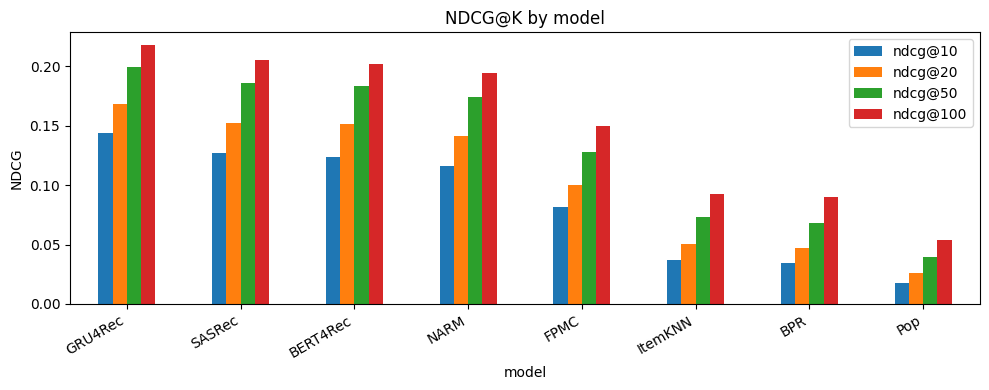

In [5]:
import matplotlib.pyplot as plt
ax = df.set_index('model')[[c for c in ['ndcg@10', 'ndcg@20', 'ndcg@50', 'ndcg@100'] if c in df.columns]].plot.bar(figsize=(10, 4))
ax.set_ylabel('NDCG'); ax.set_title('NDCG@K by model'); plt.xticks(rotation=30, ha='right'); plt.tight_layout()

## 5. Top-100 recommendations demo

Confirms the "next-1 → top-K" path: we score the entire item vocab at the next
position, mask items already in the user's history, and take the top 100. The
model below is reloaded from its checkpoint.

In [6]:
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

best_model_name = df.iloc[0]['model']
print('Best model:', best_model_name)
rec = load_result(DATASET, best_model_name)
ckpt = rec['checkpoint']

# Rebuild config + dataset and load checkpoint
from runner import _build_config
cfg, model_cls = _build_config(DATASET, best_model_name, rec.get('best_params') or {}, epochs=1, saved=True)
init_seed(cfg['seed'], cfg['reproducibility'])
dataset = create_dataset(cfg)
train_data, valid_data, test_data = data_preparation(cfg, dataset)
model_class = model_cls or get_model(cfg['model'])
model = model_class(cfg, train_data._dataset).to(cfg['device'])
model.load_state_dict(torch.load(ckpt, map_location=cfg['device'])['state_dict'])
model.eval()

sample_users = list(dataset.id2token(dataset.uid_field, np.arange(1, 4)))
topk = top_k_recommend(model, dataset, test_data, sample_users, k=100)
topk.head(15)

Best model: GRU4Rec


Max value of user's history interaction records has reached 66.60813579163009% of the total.


,user_id,rank,item_id,score
0,1,1,1094,4.605636
1,1,2,1077,4.557882
2,1,3,1079,4.523230
3,1,4,2020,4.367259
4,1,5,39,4.352442
5,1,6,348,4.336279
6,1,7,25,4.304925
7,1,8,1036,4.252697
8,1,9,2919,4.247087
9,1,10,1968,4.192613


## 6. Analysis

In [8]:
# Quick sequential-vs-non-sequential gap
is_seq = {n: (MODEL_REGISTRY[n]['type'] == 'sequential') for n in df['model']}
df_analysis = df.copy()
df_analysis['family'] = df_analysis['model'].map(lambda n: 'sequential' if is_seq[n] else 'general')
df_analysis.groupby('family')[[c for c in ['ndcg@10', 'hit@10', 'mrr@10'] if c in df_analysis.columns]].mean().round(4)

,ndcg@10,hit@10,mrr@10
family,,,
general,0.0297,0.0599,0.0207
sequential,0.1184,0.2223,0.0869


## 7. Adding a custom variant

For your next paper, drop a class into [`src/models/variants/`](../src/models/variants/)
and register it. Example:

```python
# src/models/variants/sasrec_plus.py
from recbole.model.sequential_recommender.sasrec import SASRec
import torch.nn as nn

class SASRecPlus(SASRec):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.extra_proj = nn.Linear(self.hidden_size, self.hidden_size)
    def forward(self, item_seq, item_seq_len):
        out = super().forward(item_seq, item_seq_len)
        return out + self.extra_proj(out)  # toy modification
```

Then in [`src/models/__init__.py`](../src/models/__init__.py):

```python
from models.variants.sasrec_plus import SASRecPlus
MODEL_REGISTRY['SASRecPlus'] = {
    'class': SASRecPlus,
    'type': 'sequential',
    'search_space': sasrec_space,
    'static': _seq_static(),
}
```

Re-run section 3 — only `SASRecPlus` will train; everything else loads from disk.